In [1]:
import pandas as pd

from pathlib import Path

from proteometer.params import Params
from proteometer.ptm_analysis import ptm_analysis_return_all
from proteometer.quality_control_plots import biplot
import proteometer.parse_metadata as parse_metadata


In [2]:
par = Params("PPI_yarrowia.toml")
Path(par.result_dir).mkdir(exist_ok=True, parents=True)


## Step by step analysis of Lipomyces dataset

In [42]:
import pandas as pd

import proteometer.abundance as abundance
import proteometer.normalization as normalization
import proteometer.parse_metadata as parse_metadata
import proteometer.ptm as ptm
import proteometer.rollup as rollup
import proteometer.stats as stats
from proteometer.params import Params
from proteometer.utils import filter_missingness, generate_index



In [4]:
metadata = pd.read_csv(par.metadata_file, sep="\t")
global_prot = pd.read_csv(par.global_prot_file, sep="\t")
global_pept = pd.read_csv(par.global_pept_file, sep="\t")
ptm_pept = [pd.read_csv(f, sep="\t") for f in par.ptm_pept_files]



In [5]:
int_cols = parse_metadata.int_columns(metadata, par)
anova_cols = parse_metadata.anova_columns(metadata, par)
group_cols, groups = parse_metadata.group_columns(metadata, par)
pairwise_ttest_groups = parse_metadata.t_test_groups(metadata, par)



In [6]:
ptm_pept = [
    generate_index(pept, par.uniprot_col, par.peptide_col, par.id_separator)
    for pept in ptm_pept
]


global_prot = generate_index(global_prot, par.uniprot_col)

if not par.log2_scale:  # if not already in log2, transform it
    ptm_pept = [stats.log2_transformation(pept, int_cols) for pept in ptm_pept]
    global_pept = stats.log2_transformation(global_pept, int_cols)
    global_prot = stats.log2_transformation(global_prot, int_cols)

ptm_pept = [
    filter_missingness(pept, groups, group_cols, par.min_replicates_qc)
    for pept in ptm_pept
]
global_pept = filter_missingness(global_pept, groups, group_cols, par.min_replicates_qc)
global_prot = filter_missingness(global_prot, groups, group_cols, par.min_replicates_qc)



<Axes: xlabel='PC1 (38.74%)', ylabel='PC2 (24.84%)'>

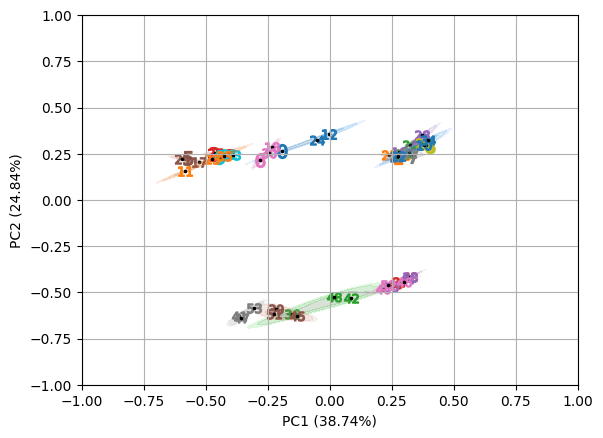

In [7]:
biplot(global_prot[int_cols].dropna(), int_cols, group_cols)

In [8]:
global_prot = normalization.median_normalization(
    global_prot,
    int_cols,
    metadata,
    par.batch_correct_samples,
    batch_col=par.metadata_batch_col,
    sample_col=par.metadata_sample_col,
)


<Axes: xlabel='PC1 (35.46%)', ylabel='PC2 (26.22%)'>

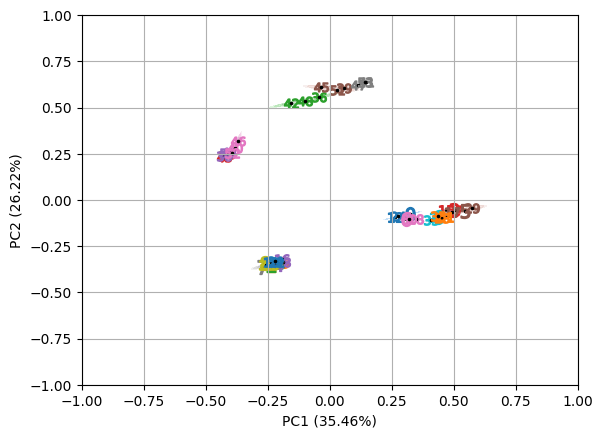

In [9]:
biplot(global_prot[int_cols].dropna(), int_cols, group_cols)

In [10]:
batch_pairs = [[["p1", ["Biostat2L_32_Control_3.5"]], ["p2", ["Biostat2L_32_Low_3.5"]]], [["p1", ["Biostat2L_30_Control_3.5", "Biostat2L_31_Control_3.5"]], ["p3", ["Biostat2L_30_Oscillation_3.5", "Biostat2L_31_Oscillation_3.5"]]]]

In [11]:
def specific_batch_correction(df4bc, batch_pairs = batch_pairs, samples = int_cols, metadata = metadata, batch_col = par.metadata_batch_col, sample_col = par.metadata_sample_col):
    """Perform batch normalization for specific samples."""
    df = df4bc.copy()
    for batch_pair in batch_pairs:
        int_cols_to_correct = metadata[metadata[batch_col] == batch_pair[1][0]][sample_col]
        batch_mean_diffs = df[batch_pair[1][1]].mean(axis=1) - df[batch_pair[0][1]].mean(axis=1)
        df[int_cols_to_correct] = df[int_cols_to_correct].sub(batch_mean_diffs, axis=0)
    return df

In [12]:
global_prot = specific_batch_correction(
    global_prot,
    batch_pairs=batch_pairs,
    samples=int_cols,
    metadata=metadata,
    batch_col=par.metadata_batch_col,
    sample_col=par.metadata_sample_col,
)


<Axes: xlabel='PC1 (51.00%)', ylabel='PC2 (14.63%)'>

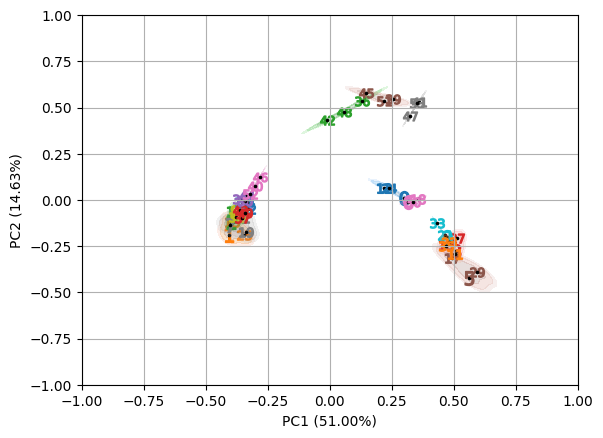

In [13]:
biplot(global_prot[int_cols].dropna(), int_cols, group_cols)

In [14]:
    if anova_cols:
        global_prot = stats.anova(
            global_prot,
            anova_cols,
            metadata,
            par.anova_factors,
            par.metadata_sample_col,
        )
    global_prot = stats.pairwise_ttest(global_prot, pairwise_ttest_groups)


In [15]:
ptm_pept = [
    normalization.peptide_normalization(
        global_pept=global_pept,
        mod_pept=pept,
        int_cols=int_cols,
        par=par,
    )
    for pept in ptm_pept
]



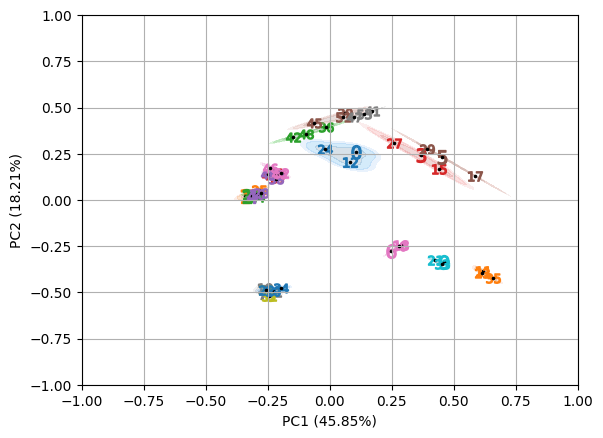

In [16]:
for pept in ptm_pept:
    biplot(pept[int_cols].dropna(), int_cols, group_cols)

In [17]:
ptm_pept_batch_corrected = [
    specific_batch_correction(
        pept,
        batch_pairs=batch_pairs,
        samples=int_cols,
        metadata=metadata,
        batch_col=par.metadata_batch_col,
        sample_col=par.metadata_sample_col,
    )
    for pept in ptm_pept
]



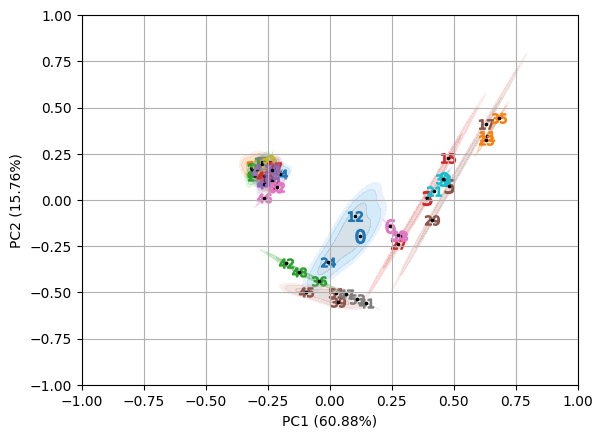

In [18]:
for pept in ptm_pept_batch_corrected:
    biplot(pept[int_cols].dropna(), int_cols, group_cols)

In [19]:
ptm_rolled_pept_batch_corrected = [
    rollup.rollup_to_site(
        pept,
        int_cols,
        par.uniprot_col,
        par.peptide_col,
        par.residue_col,
        ";",
        par.id_col,
        par.id_separator,
        par.site_col,
        rollup_func="sum",
    )
    for pept in ptm_pept_batch_corrected
]



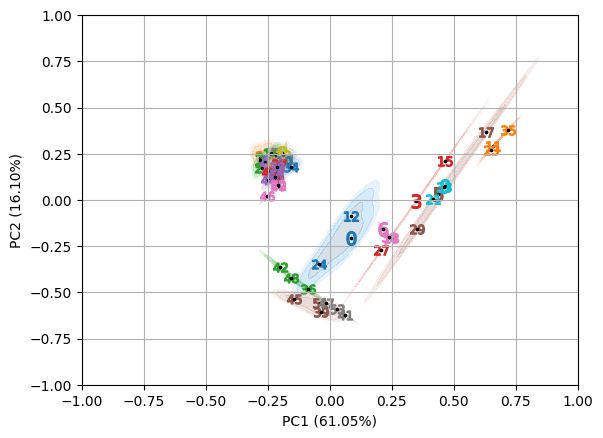

In [20]:
for pept in ptm_rolled_pept_batch_corrected:
    biplot(pept[int_cols].dropna(), int_cols, group_cols)

In [21]:
if par.batch_correction:
    ptm_rolled_pept_batch_corrected = [
        specific_batch_correction(
            mod_pept,
            batch_pairs=batch_pairs,
            samples=int_cols,
            metadata=metadata,
            batch_col=par.metadata_batch_col,
            sample_col=par.metadata_sample_col,
        )
        for mod_pept in ptm_rolled_pept_batch_corrected
    ]



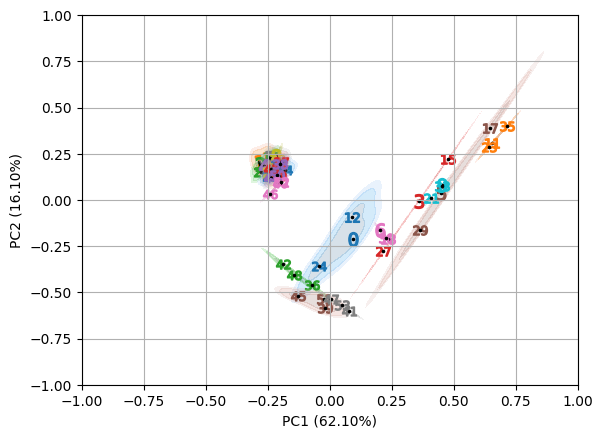

In [22]:
for pept in ptm_rolled_pept_batch_corrected:
    biplot(pept[int_cols].dropna(), int_cols, group_cols)

In [23]:
ptm_rolled = [
    rollup.rollup_to_site(
        pept,
        int_cols,
        par.uniprot_col,
        par.peptide_col,
        par.residue_col,
        ";",
        par.id_col,
        par.id_separator,
        par.site_col,
        rollup_func="sum",
    )
    for pept in ptm_pept
]



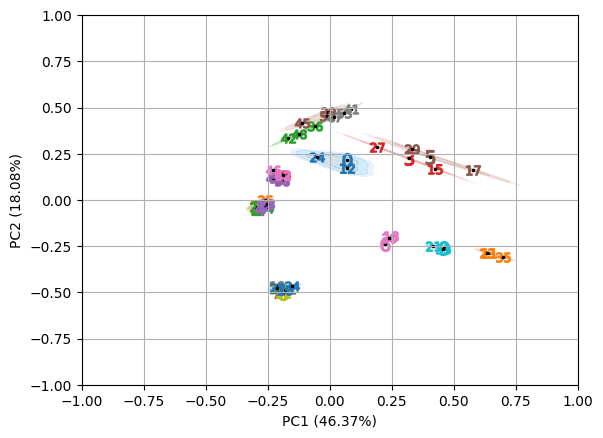

In [24]:
for pept in ptm_rolled:
    biplot(pept[int_cols].dropna(), int_cols, group_cols)

In [25]:
if par.batch_correction:
    ptm_rolled = [
        specific_batch_correction(
            mod_pept,
            batch_pairs=batch_pairs,
            samples=int_cols,
            metadata=metadata,
            batch_col=par.metadata_batch_col,
            sample_col=par.metadata_sample_col,
        )
        for mod_pept in ptm_rolled
    ]



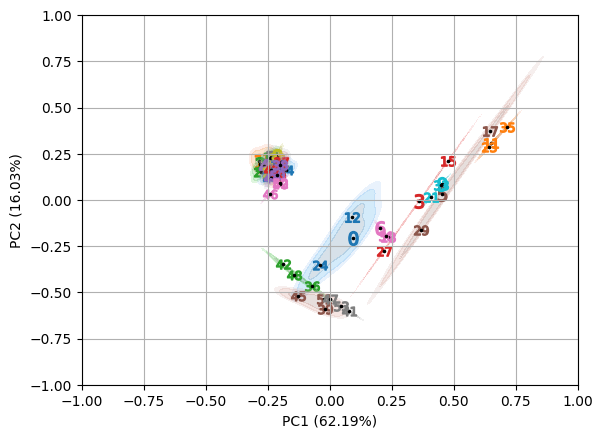

In [26]:
for pept in ptm_rolled:
    biplot(pept[int_cols].dropna(), int_cols, group_cols)

In [ ]:
from proteometer.ptm_analysis import _rollup_stats

ptm_rolled_uncorrected = ptm_rolled.copy()

ptm_rolled_uncorrected = _rollup_stats(
    ptm_rolled=ptm_rolled_uncorrected,
    anova_cols=anova_cols,
    pairwise_ttest_groups=pairwise_ttest_groups,
    metadata=metadata,
    par=par,
)

if par.abundance_correction:
    ptm_rolled = [
        abundance.prot_abund_correction(
            pept,
            global_prot,
            par,
            columns_to_correct=int_cols,
        )
        for pept in ptm_rolled
    ]

ptm_rolled = _rollup_stats(
    ptm_rolled=ptm_rolled,
    anova_cols=anova_cols,
    pairwise_ttest_groups=pairwise_ttest_groups,
    metadata=metadata,
    par=par,
)

global_prot = ptm.combine_multi_ptms({"global": global_prot}, par)
ptm_dict: dict[str, pd.DataFrame] = {}
ptm_dict.update({name: rolled for name, rolled in zip(par.ptm_names, ptm_rolled)})
all_ptms = ptm.combine_multi_ptms(ptm_dict, par)

ptm_dict_uncorrected: dict[str, pd.DataFrame] = {}
ptm_dict_uncorrected.update({name: rolled for name, rolled in zip(par.ptm_names, ptm_rolled_uncorrected)})
all_ptms_uncorrected = ptm.combine_multi_ptms(ptm_dict_uncorrected, par)

all_ptms = filter_missingness(
    all_ptms, groups, group_cols, par.min_replicates_qc
)
global_prot = filter_missingness(
    global_prot, groups, group_cols, par.min_replicates_qc
)
all_ptms_uncorrected = filter_missingness(
    all_ptms_uncorrected, groups, group_cols, par.min_replicates_qc
)


<Axes: xlabel='PC1 (70.21%)', ylabel='PC2 (9.56%)'>

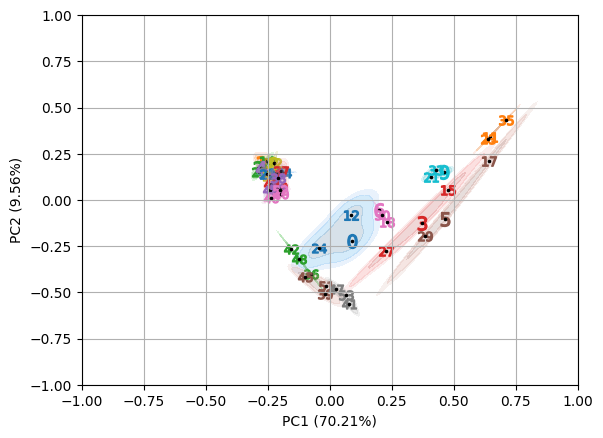

In [36]:
biplot(all_ptms[int_cols].dropna(), int_cols, group_cols)

<Axes: xlabel='PC1 (62.19%)', ylabel='PC2 (16.03%)'>

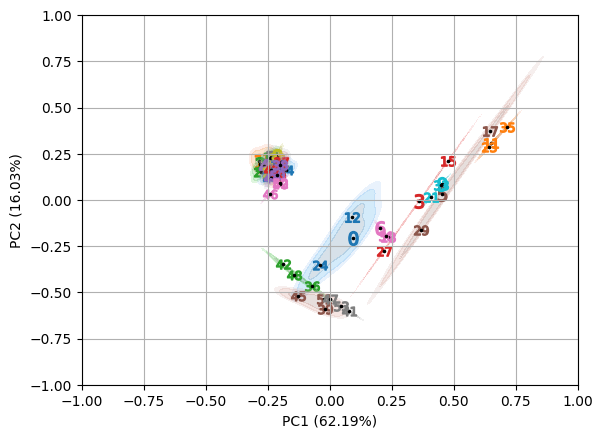

In [37]:
biplot(all_ptms_uncorrected[int_cols].dropna(), int_cols, group_cols)

<Axes: xlabel='PC1 (51.00%)', ylabel='PC2 (14.63%)'>

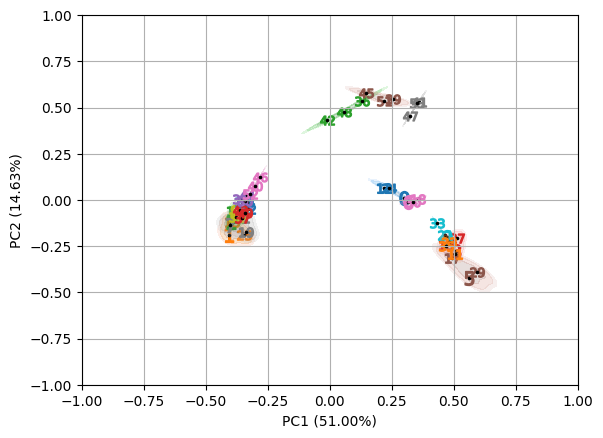

In [38]:
biplot(global_prot[int_cols].dropna(), int_cols, group_cols)

In [39]:
all_ptms.to_csv(f"{par.result_dir}/PPI_yarrowia_all_ptms.csv", index=False)
global_prot.to_csv(f"{par.result_dir}/PPI_yarrowia_protein_abundance.csv", index=False)
all_ptms_uncorrected.to_csv(f"{par.result_dir}/PPI_yarrowia_all_ptms_not_abundance_corrected.csv", index=False)


## Use single ptm_analysis function to return all results

In [27]:
# dfs = ptm_analysis_return_all(par)


In [3]:
metadata = pd.read_csv(par.metadata_file, sep='\t')
metadata

,MeasurementName,ReporterName,PlexID,QuantBlock,ReporterAlias,Sample Processing ID,Sample ID,Reactor Name,Reactor Condition,Cultivation Time (h),Time,Group,Treatment,Condition,Sample,Replicate,Batch
0,Biostat2L_29_Oscillation_24,131N,p3,1,p3_10,46,10,Biostat2L_29,Oscillation,24.0,24.0,Oscillation_24,Oscillation,Treatment,Biostat2L_29_Oscillation_24,29,p3
1,Biostat2L_29_Oscillation_3.5,127C,p3,1,p3_3,37,4,Biostat2L_29,Oscillation,3.5,3.5,Oscillation_3.5,Oscillation,Treatment,Biostat2L_29_Oscillation_3.5,29,p3
2,Biostat2L_29_Oscillation_4.5,128N,p3,1,p3_4,40,6,Biostat2L_29,Oscillation,4.5,4.5,Oscillation_4.5,Oscillation,Treatment,Biostat2L_29_Oscillation_4.5,29,p3
3,Biostat2L_29_Oscillation_48,132C,p3,1,p3_13,49,12,Biostat2L_29,Oscillation,47.5,48.0,Oscillation_48,Oscillation,Treatment,Biostat2L_29_Oscillation_48,29,p3
4,Biostat2L_29_Oscillation_5.5,129C,p3,1,p3_7,43,8,Biostat2L_29,Oscillation,5.5,5.5,Oscillation_5.5,Oscillation,Treatment,Biostat2L_29_Oscillation_5.5,29,p3
5,Biostat2L_29_Oscillation_72,134N,p3,1,p3_16,52,14,Biostat2L_29,Oscillation,72.0,72.0,Oscillation_72,Oscillation,Treatment,Biostat2L_29_Oscillation_72,29,p3
6,Biostat2L_30_Control_24,131N,p1,1,p1_10,10,23,Biostat2L_30,Control,24.0,24.0,Control_24,Control,Treatment,Biostat2L_30_Control_24,30,p1
7,Biostat2L_30_Control_3.5,126,p1,1,p1_1,1,17,Biostat2L_30,Control,3.5,3.5,Control_3.5,Control,Treatment,Biostat2L_30_Control_3.5,30,p1
8,Biostat2L_30_Control_4.5,128N,p1,1,p1_4,4,19,Biostat2L_30,Control,4.5,4.5,Control_4.5,Control,Treatment,Biostat2L_30_Control_4.5,30,p1
9,Biostat2L_30_Control_48,132C,p1,1,p1_13,13,25,Biostat2L_30,Control,48.0,48.0,Control_48,Control,Treatment,Biostat2L_30_Control_48,30,p1


In [4]:
# dfs[0].to_csv(f"{par.result_dir}/PPI_lipomyces_all_ptm.csv", index=False)
# dfs[1].to_csv(f"{par.result_dir}/PPI_lipomyces_protein_abundance.csv", index=False)
# dfs[2].to_csv(f"{par.result_dir}/PPI_lipomyces_all_ptm_not_abundance_corrected.csv", index=False)


In [5]:
all_ptms = pd.read_csv(f"{par.result_dir}/PPI_yarrowia_all_ptms.csv")
all_ptms_uncorrected = pd.read_csv(f"{par.result_dir}/PPI_yarrowia_all_ptms_not_abundance_corrected.csv")
protein_abundance = pd.read_csv(f"{par.result_dir}/PPI_yarrowia_protein_abundance.csv")

In [6]:
int_cols = parse_metadata.int_columns(metadata, par)
group_cols, groups = parse_metadata.group_columns(metadata, par)

<Axes: xlabel='PC1 (70.21%)', ylabel='PC2 (9.56%)'>

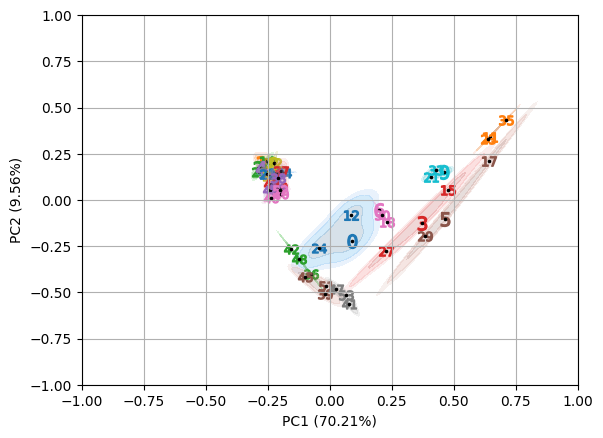

In [7]:
biplot(all_ptms[int_cols].dropna(), int_cols, group_cols)

<Axes: xlabel='PC1 (62.19%)', ylabel='PC2 (16.03%)'>

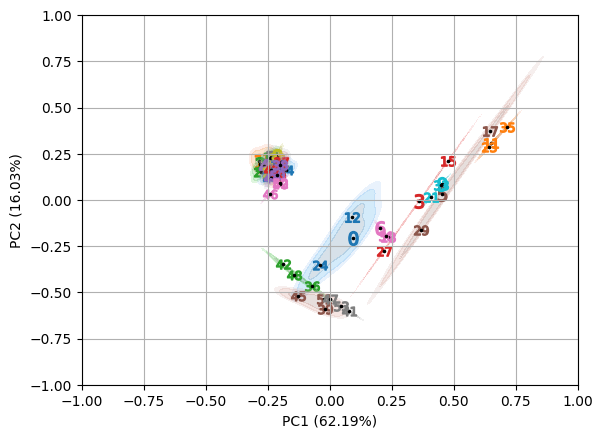

In [8]:
biplot(all_ptms_uncorrected[int_cols].dropna(), int_cols, group_cols)

<Axes: xlabel='PC1 (51.00%)', ylabel='PC2 (14.63%)'>

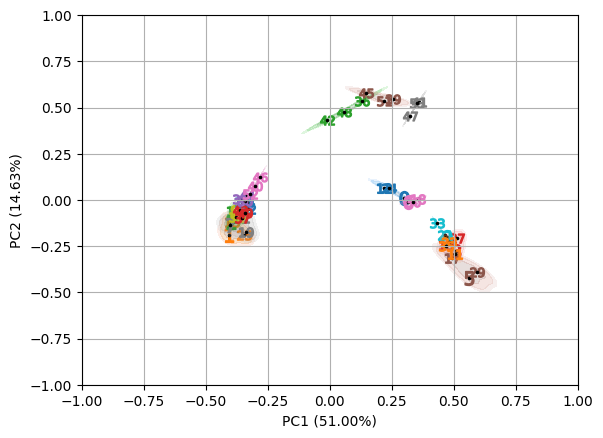

In [9]:
biplot(protein_abundance[int_cols].dropna(), int_cols, group_cols)

In [19]:
import proteometer.quality_control_plots as qcp
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [15, 12]


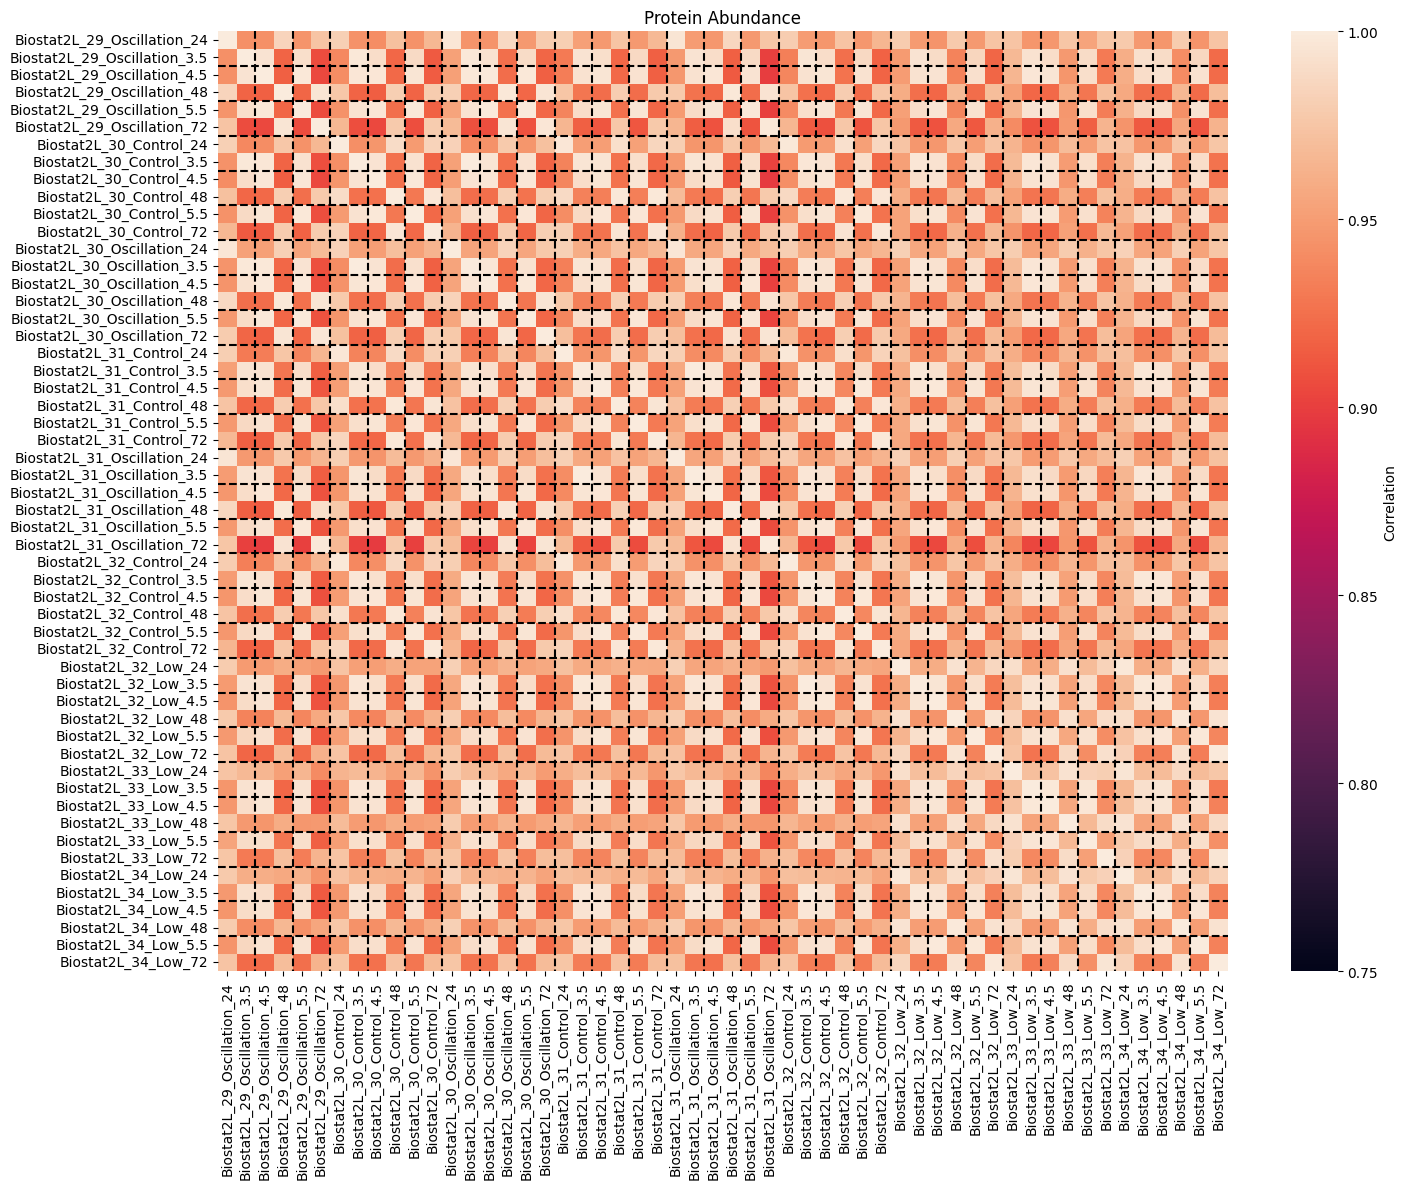

In [20]:
fig, ax = plt.subplots(1, 1)
qcp.correlation_plot(
    protein_abundance,
    [c for c in int_cols if "Total" not in c],
    ax=ax,
)
ax.set_title("Protein Abundance")
ax.hlines(
    range(2, len(int_cols), 2),
    0,
    len(int_cols) + 2,
    colors="k",
    linestyles="dashed",
)
ax.vlines(
    range(2, len(int_cols), 2),
    0,
    len(int_cols) + 2,
    colors="k",
    linestyles="dashed",
)
fig.tight_layout()
plt.show()

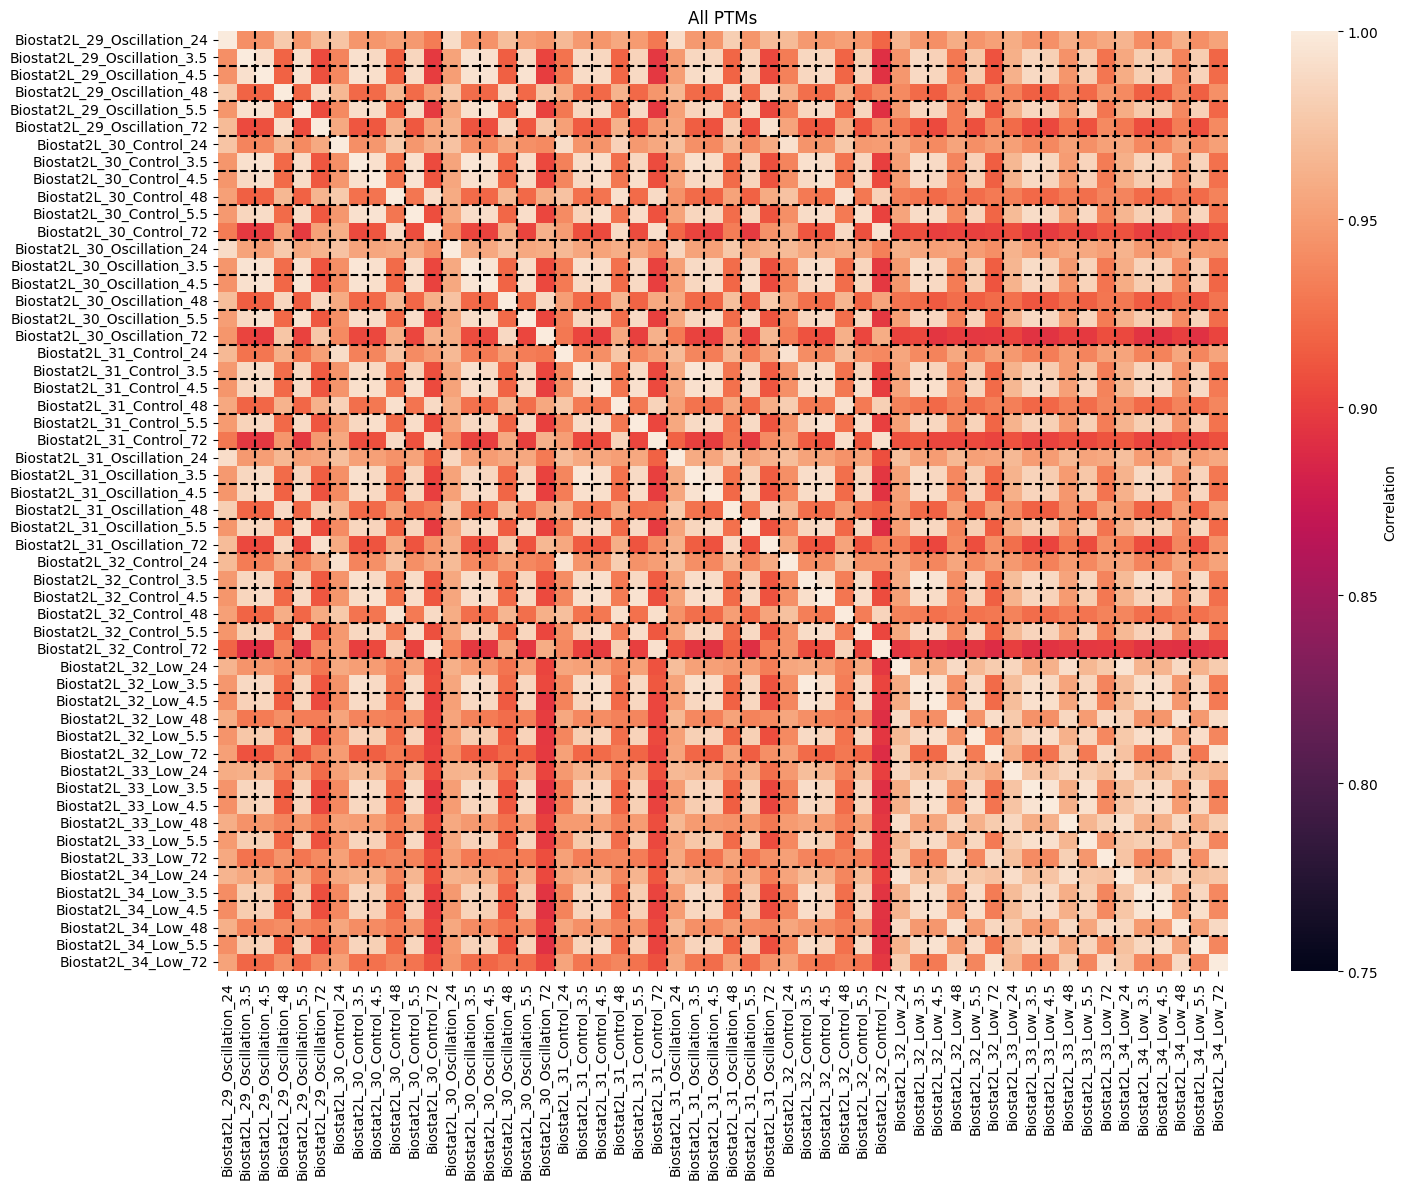

In [21]:
fig, ax = plt.subplots(1, 1)
qcp.correlation_plot(
    all_ptms,
    [c for c in int_cols if "Total" not in c],
    ax=ax,
)
ax.set_title("All PTMs")
ax.hlines(
    range(2, len(int_cols), 2),
    0,
    len(int_cols) + 2,
    colors="k",
    linestyles="dashed",
)
ax.vlines(
    range(2, len(int_cols), 2),
    0,
    len(int_cols) + 2,
    colors="k",
    linestyles="dashed",
)
fig.tight_layout()
plt.show()

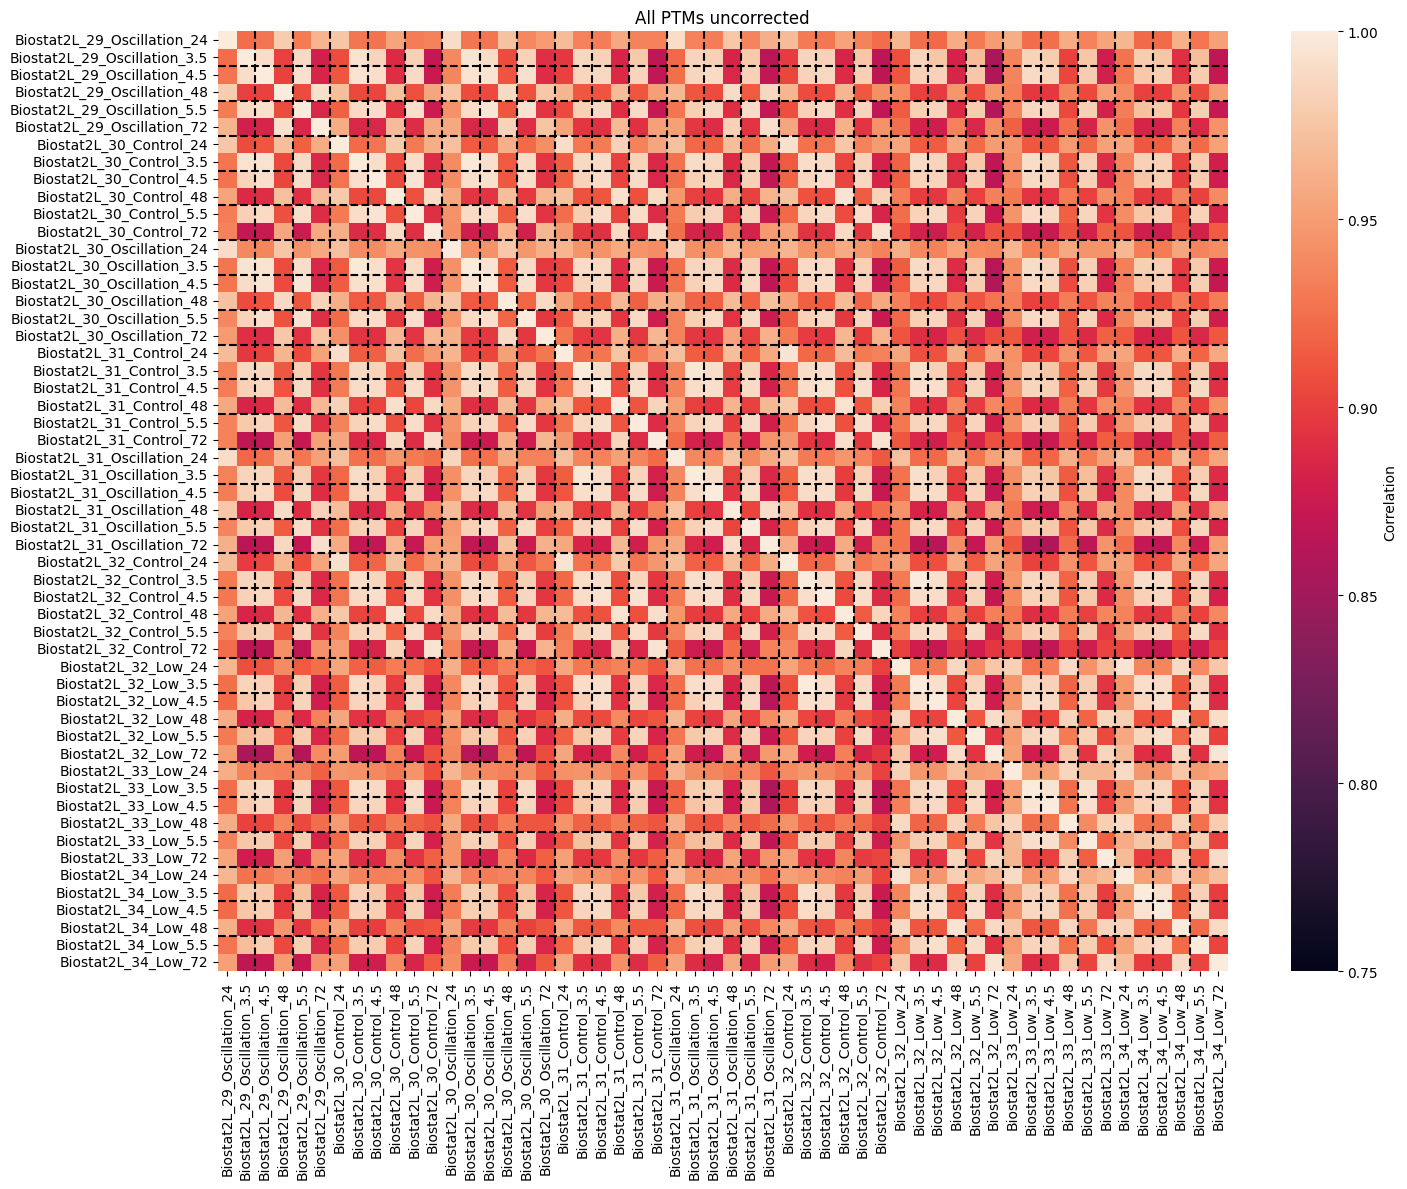

In [22]:
fig, ax = plt.subplots(1, 1)
qcp.correlation_plot(
    all_ptms_uncorrected,
    [c for c in int_cols if "Total" not in c],
    ax=ax,
)
ax.set_title("All PTMs uncorrected")
ax.hlines(
    range(2, len(int_cols), 2),
    0,
    len(int_cols) + 2,
    colors="k",
    linestyles="dashed",
)
ax.vlines(
    range(2, len(int_cols), 2),
    0,
    len(int_cols) + 2,
    colors="k",
    linestyles="dashed",
)
fig.tight_layout()
plt.show()